### Vizualization of purely Data Driven approach to measuring exploration

"Whether a model has explored can be measured by the surrpise of the rollouts of the trained model under the base model".

Setup: I've collected validation rollouts during training. For GRPO and Kl-cov, for every checkpoint present in their respective checkpoint directories,
I calculated the logprobs for these validation rollouts. 


In [1]:
import pandas as pd
import os
import numpy as np

In [2]:
paths = [
    '/ptmp/rfechner/out/exp04/llama_3.2_1b_instruct__grpo/val_jsonl',
    "/ptmp/rfechner/out/exp04/llama_3.2_1b_instruct__kl-cov/val_jsonl"
]

In [3]:
def gather_logprobs(path : str):
    checkpoint_results = []
    files = list(filter(lambda x: x.endswith('_precomp.jsonl'), os.listdir(path)))
    files = list(sorted(files, key=lambda x: int(x.split('_')[0])))
    files = [files[0], files[-1]]
    print('Processing only first and last.')
    
    for file in files:
        print(f'Processing file: {file}')
        chunks = pd.read_json(os.path.join(path, file), lines=True, chunksize=1000)
        chunk_dicts = []
        counter = 0
        for chunk in chunks:
            tmp = {
                'input_hash' : chunk['input'].apply(lambda x: hash(x)),
                'logprobs' : chunk['logprobs'].apply(np.mean),
                'entropy' : chunk['entropy'].apply(np.mean),
                'score' : chunk['score'],
                'checkpoint_global_step' : chunk['checkpoint_global_step'],
                'data_global_step' : chunk['data_global_step'],
            }
            chunk_dicts.append(tmp)
            counter += 1
        df = pd.concat([pd.DataFrame(entry) for entry in chunk_dicts])
        checkpoint_results.append(df)
    return checkpoint_results

In [4]:
def gather_logprobs_with_percentile(path : str):
    checkpoint_results = []
    files = list(filter(lambda x: x.endswith('_precomp.jsonl'), os.listdir(path)))
    files = list(sorted(files, key=lambda x: int(x.split('_')[0])))
    files = [files[0], files[-1]]
    print('Processing only first and last.')
    
    for file in files:
        print(f'Processing file: {file}')
        chunks = pd.read_json(os.path.join(path, file), lines=True, chunksize=1000)
        chunk_dicts = []
        counter = 0
        for chunk in chunks:
            suffix_percentiles = {
                f'suffix_{k}_logprobs' : chunk['logprobs'].apply(lambda x: np.mean(x[k:]) if k < len(x) else np.mean(x)) \
                    for k in [10, 20, 50, 100, 200, 300]
            }

            prefix_percentiles = {
                f'prefix_{k}_logprobs' : chunk['logprobs'].apply(lambda x: np.mean(x[:k]) if k < len(x) else np.mean(x)) \
                    for k in [10, 20, 50, 100, 200, 300]
            }
            tmp = {
                'input_hash' : chunk['input'].apply(lambda x: hash(x)),
                'logprobs' : chunk['logprobs'].apply(np.mean),
                'logprobs' : chunk['logprobs'].apply(np.mean),
                'entropy' : chunk['entropy'].apply(np.mean),
                'score' : chunk['score'],
                'checkpoint_global_step' : chunk['checkpoint_global_step'],
                'data_global_step' : chunk['data_global_step'],
                **suffix_percentiles,
                **prefix_percentiles
            }
            chunk_dicts.append(tmp)
            counter += 1
        df = pd.concat([pd.DataFrame(entry) for entry in chunk_dicts])
        checkpoint_results.append(df)
    return checkpoint_results

In [5]:
RELOAD = False
import pickle
root="/u/rfechner/verl/workspace/plots/.tmpfiles"
os.makedirs(root, exist_ok=True)

if RELOAD:
    mapper = {}
    for path in paths:
        outs = gather_logprobs_with_percentile(path)
        mapper[path] = outs

    with open(os.path.join(root, 'gather_logprobs_with_percentile.pickle'), 'wb') as file:
        pickle.dump(obj=mapper, file=file)
else:
    with open(os.path.join(root, 'gather_logprobs_with_percentile.pickle'), 'rb') as file:
        mapper = pickle.load(file=file)


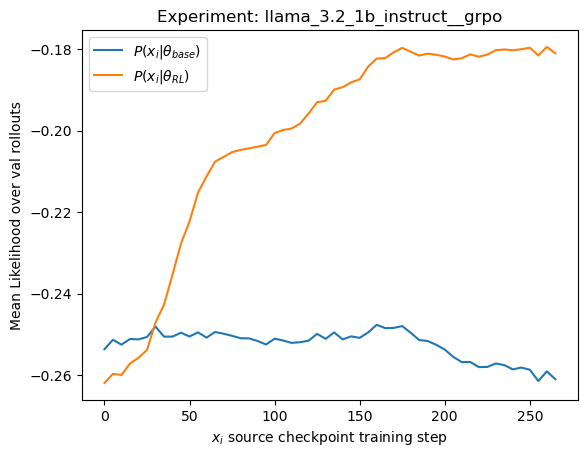

In [6]:
import matplotlib.pyplot as plt
VAL_FREQ = 5
def plot(experiment_name : str, outs : list[pd.DataFrame]) -> None:
    first, last = outs
    first_values, last_values = [], []
    first_stds, last_stds = [], []

    groups = first.groupby('data_global_step', sort=True)
    for data_step, group in groups:
        first_values.append(group['logprobs'].to_numpy().mean())
        first_stds.append(group['logprobs'].to_numpy().std())

    groups = last.groupby('data_global_step', sort=True)
    for data_step, group in groups:
        last_values.append(group['logprobs'].to_numpy().mean())
        last_stds.append(group['logprobs'].to_numpy().std())

    plt.errorbar(x=range(0, len(first_values) * VAL_FREQ, VAL_FREQ), y=first_values, label='$P(x_i|\\theta_{base})$')
    plt.errorbar(x=range(0, len(last_values) * VAL_FREQ, VAL_FREQ), y=last_values, label='$P(x_i|\\theta_{RL})$')
    plt.ylabel('Mean Likelihood over val rollouts')
    plt.xlabel('$x_i$ source checkpoint training step')
    plt.title(f'Experiment: {experiment_name}')
    plt.legend()
    plt.show()

name = '/ptmp/rfechner/out/exp04/llama_3.2_1b_instruct__grpo/val_jsonl'
experiment_name = "llama_3.2_1b_instruct__grpo"
plot(experiment_name, mapper[name])

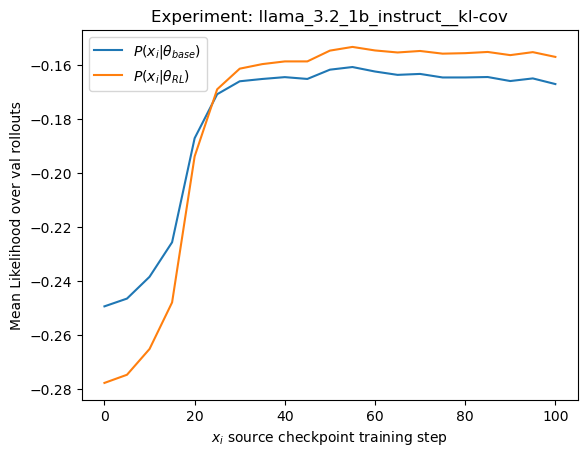

In [7]:
name = '/ptmp/rfechner/out/exp04/llama_3.2_1b_instruct__kl-cov/val_jsonl'
experiment_name = "llama_3.2_1b_instruct__kl-cov"
plot(experiment_name, mapper[name])

In [8]:
outs_only_pos = {
    m : [df[df['score'] == 1] for df in v] for m, v in mapper.items()
}

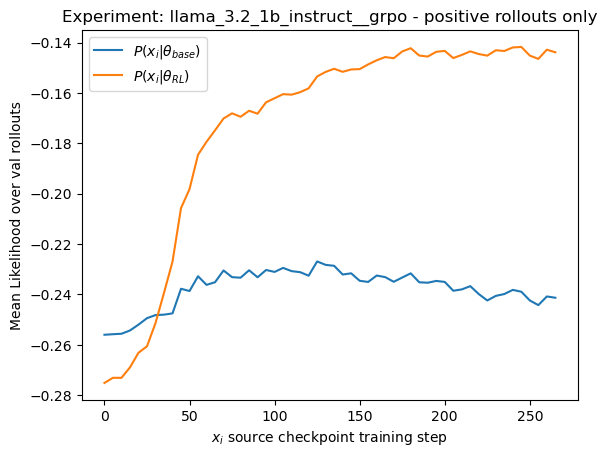

In [9]:
name = '/ptmp/rfechner/out/exp04/llama_3.2_1b_instruct__grpo/val_jsonl'
experiment_name = "llama_3.2_1b_instruct__grpo - positive rollouts only"
plot(experiment_name, outs_only_pos[name])

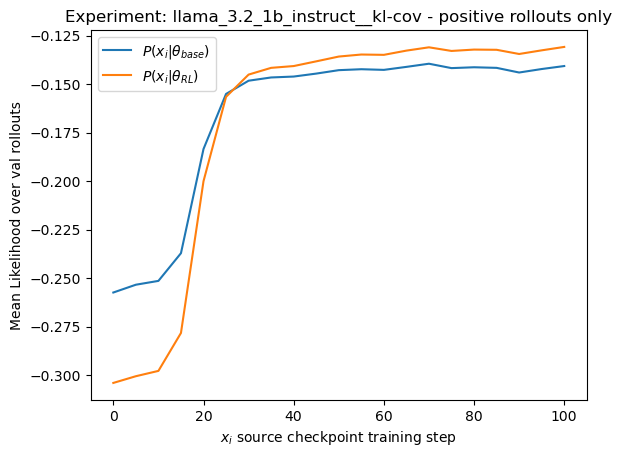

In [10]:
name = '/ptmp/rfechner/out/exp04/llama_3.2_1b_instruct__kl-cov/val_jsonl'
experiment_name = "llama_3.2_1b_instruct__kl-cov - positive rollouts only"
plot(experiment_name, outs_only_pos[name])

In [11]:
import matplotlib.pyplot as plt

In [25]:
import matplotlib.cm as cm
plotdir = os.path.join(root, 'plots')
os.makedirs(plotdir, exist_ok=True)


# Enable LaTeX for all text
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
})

VAL_FREQ = 5
K_VALUES = [10, 20, 50, 100, 200, 300]

def plot_prefix_suffix(experiment_name: str, outs: list[pd.DataFrame], plotname_prefix=None) -> None:
    first, last = outs

    cmap = cm.get_cmap('viridis', len(K_VALUES))

    # ---------- compute stats ----------
    def compute_stats(df, colname):
        values, stds = [], []
        groups = df.groupby("data_global_step", sort=True)
        for _, group in groups:
            arr = group[colname].to_numpy()
            values.append(arr.mean())
            stds.append(arr.std())
        return values, stds

    # ---------- FIGURE ----------
    fig, (ax1, ax2) = plt.subplots(
        nrows=1, ncols=2, sharey=False, figsize=(12, 4)
    )

    # ==========================================================
    # ===================== SUFFIX PLOT =========================
    # ==========================================================

    for i, k in enumerate(K_VALUES):
        col = f"suffix_{k}_logprobs"
        first_vals, _ = compute_stats(first, col)
        last_vals, _  = compute_stats(last, col)

        xs_first = np.arange(0, len(first_vals) * VAL_FREQ, VAL_FREQ)
        xs_last  = np.arange(0, len(last_vals)  * VAL_FREQ, VAL_FREQ)

        color = cmap(i)
        ax1.errorbar(xs_first, first_vals, label=fr"$k={k},\,\theta_{{base}}$", 
                     color=color, linestyle="--")
        ax1.errorbar(xs_last, last_vals, label=fr"$k={k},\,\theta_{{RL}}$", 
                     color=color)

    ax1.set_ylabel(r"$p(x[k{:}] \mid \theta_j)$", fontsize=12)
    ax1.set_xlabel(r"$x[k:]$ \textbf{ source checkpoint training step}", fontsize=11)
    ax1.set_title(r"\textbf{Suffix likelihoods } $p(x[k{:}] \mid \theta_j)$", fontsize=13)

    # ==========================================================
    # ===================== PREFIX PLOT =========================
    # ==========================================================

    for i, k in enumerate(K_VALUES):
        col = f"prefix_{k}_logprobs"
        first_vals, _ = compute_stats(first, col)
        last_vals, _  = compute_stats(last, col)

        xs_first = np.arange(0, len(first_vals) * VAL_FREQ, VAL_FREQ)
        xs_last  = np.arange(0, len(last_vals)  * VAL_FREQ, VAL_FREQ)

        color = cmap(i)
        ax2.errorbar(xs_first, first_vals, label=fr"$k={k},\,\theta_{{base}}$", 
                     color=color, linestyle="--")
        ax2.errorbar(xs_last, last_vals, label=fr"$k={k},\,\theta_{{RL}}$", 
                     color=color)

    ax2.set_ylabel(r"$p(x[:k] \mid \theta_j)$", fontsize=12)
    ax2.set_xlabel(r"$x[:k]$ \textbf{ source checkpoint training step}", fontsize=11)
    ax2.set_title(r"\textbf{Prefix likelihoods } $p(x[:k] \mid \theta_j)$", fontsize=13)

    # ---------- Title ----------
    model, method = experiment_name.split("__")
    plt.suptitle(
        rf"\textbf{{Model:}} {model} \qquad \textbf{{Method:}} {method}",
        fontsize=14
    )

    # ---------- Legend ----------
    plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left", fontsize=9)

    plt.savefig(os.path.join(plotdir, f"{plotname_prefix + '-' if plotname_prefix else ''}{experiment_name}_prefix_suffix_plot.pdf"), dpi=300, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_15048/3273683566.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(K_VALUES))


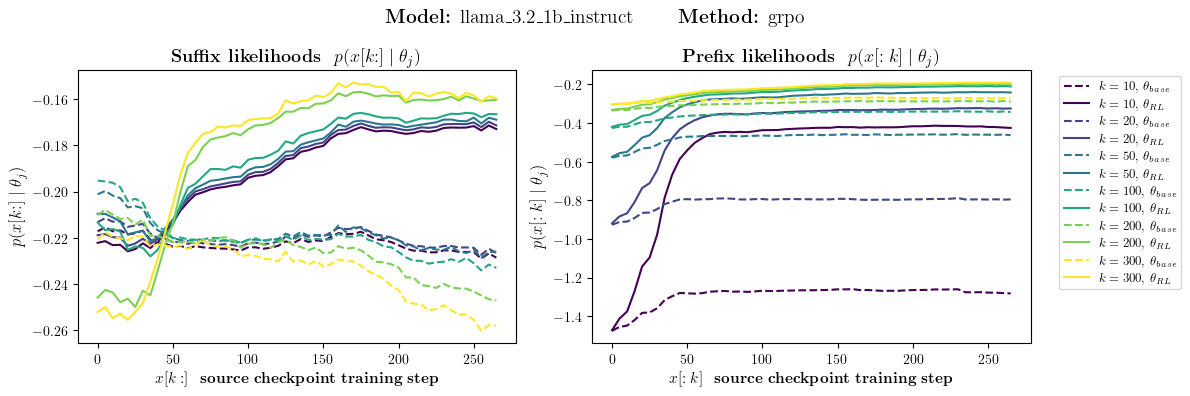

In [26]:
name = '/ptmp/rfechner/out/exp04/llama_3.2_1b_instruct__grpo/val_jsonl'
experiment_name = "llama_3.2_1b_instruct__grpo"
plot_prefix_suffix(experiment_name, mapper[name])

/tmp/ipykernel_15048/3273683566.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(K_VALUES))


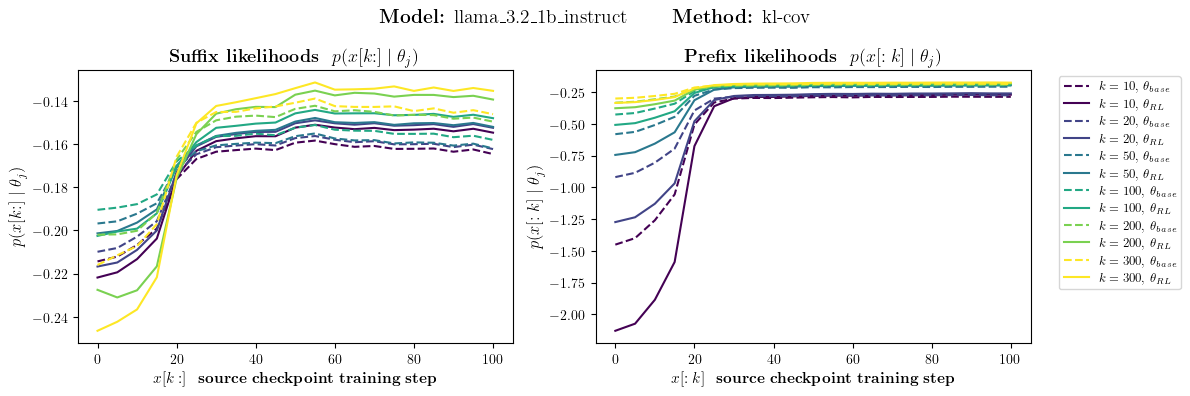

In [27]:
name = '/ptmp/rfechner/out/exp04/llama_3.2_1b_instruct__kl-cov/val_jsonl'
experiment_name = "llama_3.2_1b_instruct__kl-cov"
plot_prefix_suffix(experiment_name, mapper[name])

## Repeat for positive only trajectories

In [28]:
outs_only_pos = {
    m : [df[df['score'] == 1] for df in v] for m, v in mapper.items()
}

/tmp/ipykernel_15048/3273683566.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(K_VALUES))


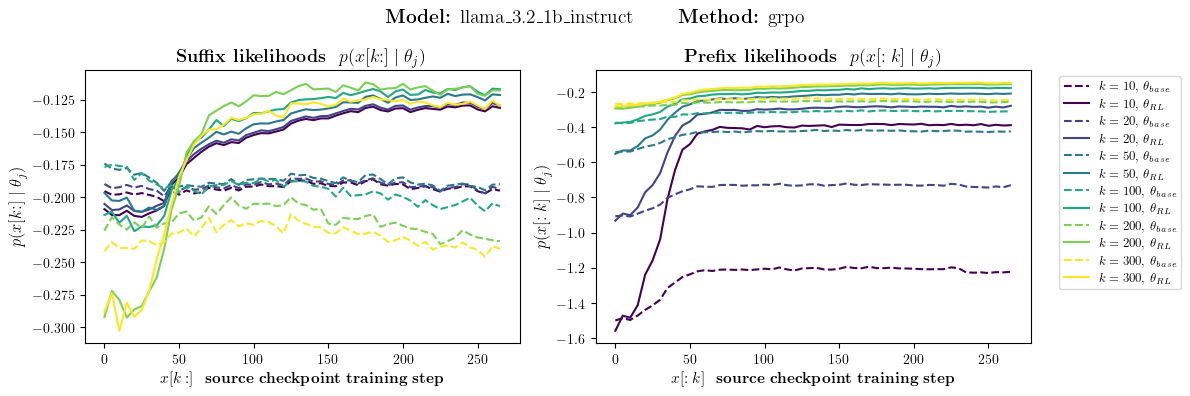

In [29]:
name = '/ptmp/rfechner/out/exp04/llama_3.2_1b_instruct__grpo/val_jsonl'
experiment_name = "llama_3.2_1b_instruct__grpo"
plot_prefix_suffix(experiment_name, outs_only_pos[name], plotname_prefix='only_positive')

/tmp/ipykernel_15048/3273683566.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(K_VALUES))


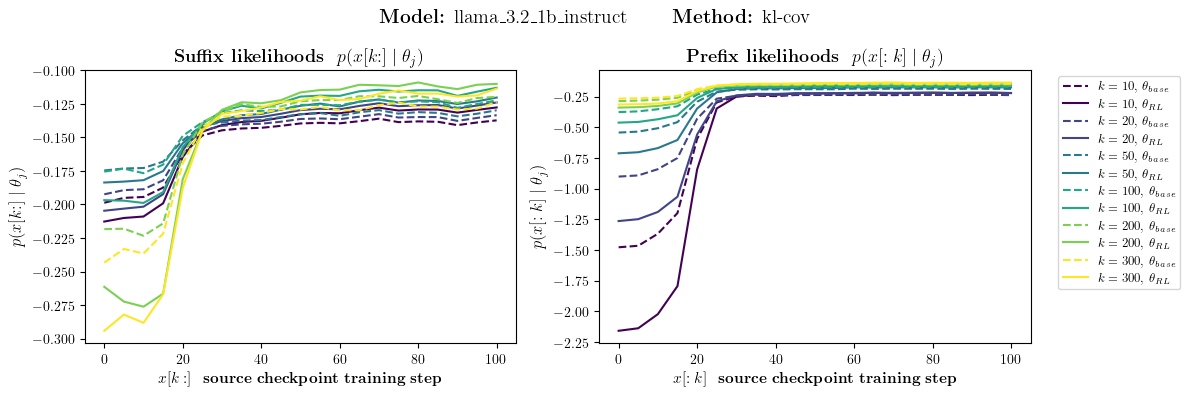

In [30]:
name = '/ptmp/rfechner/out/exp04/llama_3.2_1b_instruct__kl-cov/val_jsonl'
experiment_name = "llama_3.2_1b_instruct__kl-cov"
plot_prefix_suffix(experiment_name, outs_only_pos[name], plotname_prefix='only_positive')